## Task:
1. process desc,hood(features)
2. classify room_type
3. predict price(in thousands)

### Loading Batch Data Using Batch Learning Technique

In [1]:
import pandas as pd
import numpy as np
def load_data(url):
    return pd.read_csv(url)
data = load_data("data.csv")
data.head(2)
data.columns = ["DESC","HOOD","price","room_type"]

In [2]:
from sklearn.model_selection import train_test_split
train_set,test_set =train_test_split(data,test_size=0.2,random_state=42)

In [3]:
len(train_set),len(test_set)

(43, 11)

In [4]:
import re
from collections import Counter
from nltk.stem import PorterStemmer
train_word = train_set["DESC"]
stemmer = PorterStemmer()
Counter([stemmer.stem(x) for x in re.sub(r'[^\w\s]','',train_word[0].lower().strip()).split()])

Counter({'cozi': 1,
         'apart': 1,
         'in': 1,
         'the': 1,
         'heart': 1,
         'of': 1,
         'downtown': 1})

In [5]:
from sklearn.base import BaseEstimator,TransformerMixin
from scipy.sparse import csr_matrix
class WordVectorizer(TransformerMixin,BaseEstimator):
    def __init__(self,size=65):
        self.size=size
        
    def fit(self,X,y=None):
        counters = self.make_counters(X)
        PrevCounter = Counter()
        GodCounter = Counter()
        for i in counters:
            for word,count in i.items():
                PrevCounter[word] += count
        for word,count in PrevCounter.most_common()[:self.size]:
            GodCounter[word] = count
        self.vocab = {word:index+1 for index,(word,count) in enumerate(GodCounter.items())}
        return self
    
    def transform(self,X,y=None):
        counters = self.make_counters(X)
        rows=[]
        cols=[]
        data=[]
        for row,i in enumerate(counters):
            for word,count in i.items():
                data.append(count)
                cols.append(self.vocab.get(word,0))
                rows.append(row)
        return csr_matrix((data,(rows,cols)),shape=(len(X),self.size+1))
    
    def make_counters(self,x):
        counters = []
        for i in x:
            counters.append(Counter([stemmer.stem(j) for j in re.sub(r'[^\w\s]','',i.lower().strip()).split()]))
        return counters

In [6]:
vectorizer = WordVectorizer()

In [7]:
vectorizer.fit_transform(train_set["DESC"]).toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [4, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0]], dtype=int32)

In [8]:
train_set.describe()

,price
count,43.000000
mean,121.744186
std,51.603845
min,50.000000
25%,85.000000
50%,110.000000
75%,145.000000
max,300.000000


In [9]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 43 entries, 8 to 38
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   DESC       43 non-null     object
 1   HOOD       43 non-null     object
 2   price      43 non-null     int64 
 3   room_type  42 non-null     object
dtypes: int64(1), object(3)
memory usage: 2.7+ KB


In [10]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")
x=imputer.fit_transform(train_set)

In [11]:
train_set=pd.DataFrame(x,columns=train_set.columns)
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   DESC       43 non-null     object
 1   HOOD       43 non-null     object
 2   price      43 non-null     object
 3   room_type  43 non-null     object
dtypes: object(4)
memory usage: 1.5+ KB


In [12]:
train_set["HOOD"].value_counts()


 Mountain         4
 Urban            4
 Artsy            4
 Skyline          4
 Suburban         3
 Midtown          3
 Wilderness       3
 Historic         3
 Downtown         3
 Beachfront       3
 Riverside        2
 Beachside        1
 Historic         1
 Bohemian         1
 Financial        1
 Uptown           1
 Village          1
 Rural            1
Name: HOOD, dtype: int64

In [42]:
test_set[test_set["HOOD"]==" Lakeside     "]
test_set.drop(32,axis=0,inplace=True)

In [13]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
encoder = OneHotEncoder()
encoder.fit_transform(train_set[["HOOD"]])

<43x18 sparse matrix of type '<class 'numpy.float64'>'
	with 43 stored elements in Compressed Sparse Row format>

In [14]:
encoder.categories_

[array([' Artsy        ', ' Beachfront   ', ' Beachside    ',
        ' Bohemian     ', ' Downtown     ', ' Financial    ', ' Historic ',
        ' Historic     ', ' Midtown      ', ' Mountain     ',
        ' Riverside    ', ' Rural        ', ' Skyline      ',
        ' Suburban     ', ' Uptown       ', ' Urban        ',
        ' Village      ', ' Wilderness   '], dtype=object)]

In [15]:
encoder.fit_transform(train_set[["HOOD"]]).toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0

In [16]:
train_set["room_type"].value_counts()

 Entire home/apt       33
 Private room          10
Name: room_type, dtype: int64

In [17]:
label_encoder =OrdinalEncoder()
label_encoder.fit_transform(train_set[["room_type"]]).ravel()

array([1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0.])

### Preparing Data for ML ALGORITHMS

In [18]:
train_class_set_feature = train_set.iloc[:,0:2]
train_class_set_label = label_encoder.fit_transform(train_set[["room_type"]]).ravel()
train_class_set_feature

,DESC,HOOD
0,Peaceful retreat near the mountains.,Mountain
1,Cozy room in a historic district.,Historic
2,Cozy bungalow with garden view.,Suburban
3,Cityview condo with balcony.,Urban
4,Modern condo with city skyline views.,Midtown
5,Secluded mountain retreat.,Mountain
6,Quaint cottage with a garden view.,Suburban
7,Riverside retreat with a private dock.,Riverside
8,Charming guesthouse in a historic area.,Historic
9,Artsy loft in a creative neighborhood.,Artsy


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("ONEHOT",OneHotEncoder())
])
transformer = ColumnTransformer([
    ("WORDVECTOR",WordVectorizer(),["DESC"]),
    ("CATVECOTR",cat_pipeline,["HOOD"])
])
data_transfromed = transformer.fit_transform(train_class_set_feature)

## Selecting A ML MODEL

In [20]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(data_transfromed,train_class_set_label)

KNeighborsClassifier()

In [21]:
model.predict(transformer.transform(train_class_set_feature.iloc[32:33,:]))

array([0.])

In [22]:
train_class_set_label[32]

1.0

## CROSS-VALIDATION

In [23]:
from sklearn.model_selection import cross_val_predict,cross_val_score
y_pred = cross_val_predict(model,data_transfromed,train_class_set_label,cv=3)
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
confusion_matrix(train_class_set_label,y_pred)

array([[32,  1],
       [ 9,  1]], dtype=int64)

In [24]:
precision_score(train_class_set_label,y_pred,average='weighted',zero_division=0)

0.7152580828133863

In [25]:
recall_score(train_class_set_label,y_pred,average='weighted',zero_division=0)

0.7674418604651163

In [26]:
f1_score(train_class_set_label,y_pred,average='weighted',zero_division=0)

0.7024931908652838

In [27]:
32/43*100

74.4186046511628

# Thresholds

### Regualarization

In [28]:
from sklearn.model_selection import RandomizedSearchCV
params = [
    {'n_neighbors':[1,2,3,4,5,6,7,8],'leaf_size':[10,20,30,40,55,60]},
    {'n_neighbors':[1,2,3,4,5,6,7,8],'leaf_size':[10,20,30,40,55,60],'weights':['uniform','distance']}
]
model_random = RandomizedSearchCV(model,params,cv=5,verbose=3,return_train_score=True,random_state=42,scoring="accuracy")

In [29]:
model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [30]:
model_random.fit(data_transfromed,train_class_set_label)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END leaf_size=55, n_neighbors=3, weights=distance;, score=(train=0.912, test=0.556) total time=   0.0s
[CV 2/5] END leaf_size=55, n_neighbors=3, weights=distance;, score=(train=0.912, test=0.889) total time=   0.0s
[CV 3/5] END leaf_size=55, n_neighbors=3, weights=distance;, score=(train=0.912, test=0.778) total time=   0.0s
[CV 4/5] END leaf_size=55, n_neighbors=3, weights=distance;, score=(train=0.914, test=0.750) total time=   0.0s
[CV 5/5] END leaf_size=55, n_neighbors=3, weights=distance;, score=(train=1.000, test=0.500) total time=   0.0s
[CV 1/5] END leaf_size=30, n_neighbors=4;, score=(train=0.824, test=0.778) total time=   0.0s
[CV 2/5] END leaf_size=30, n_neighbors=4;, score=(train=0.794, test=0.889) total time=   0.0s
[CV 3/5] END leaf_size=30, n_neighbors=4;, score=(train=0.765, test=0.778) total time=   0.0s
[CV 4/5] END leaf_size=30, n_neighbors=4;, score=(train=0.857, test=0.750) total time=   0.0s
[CV

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions=[{'leaf_size': [10, 20, 30, 40, 55, 60],
                                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7,
                                                         8]},
                                        {'leaf_size': [10, 20, 30, 40, 55, 60],
                                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7,
                                                         8],
                                         'weights': ['uniform', 'distance']}],
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=3)

In [31]:
model_random.best_params_

{'weights': 'distance', 'n_neighbors': 1, 'leaf_size': 40}

In [32]:
model_random.best_score_

0.7416666666666666

In [33]:
from sklearn.metrics import precision_recall_curve

# Assuming `model_random`, `data_transformed`, and `train_class_set_label` are defined

# Calculate y_scores using cross_val_predict
y_scores = cross_val_predict(model_random.best_estimator_, data_transfromed, train_class_set_label, cv=3, method="predict_proba")[:, 0]
threshold = 0.2  # You can adjust this threshold based on your data
y_scores[y_scores < threshold] = threshold

# Calculate precision-recall curve with zero_division parameter
precision, recall, thresholds = precision_recall_curve(train_class_set_label, y_scores)

# Rest of your code...


In [34]:
import warnings
from sklearn.metrics import precision_recall_curve

# Suppress UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UserWarning)

# Assuming `model_random`, `data_transformed`, and `train_class_set_label` are defined

# Calculate y_scores using cross_val_predict
y_scores = cross_val_predict(model_random.best_estimator_, data_transfromed, train_class_set_label, cv=3, method="predict_proba")[:, 0]

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(train_class_set_label, y_scores)


In [35]:
# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(train_class_set_label, y_scores)

# Handle zero division by checking if precision is ill-defined
if not any(precision):
    precision = [0.0] * len(precision)


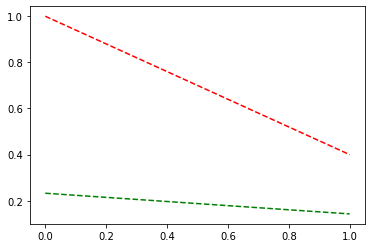

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(thresholds,precision[:-1],'g--')
plt.plot(thresholds,recall[:-1],'r--')
plt.show()

# Testing CLASS

In [44]:
test_set_1 = test_set.iloc[:,0:2]
y_test = label_encoder.fit_transform(test_set[["room_type"]]).ravel()
y_pred_test = model_random.best_estimator_.predict(transformer.transform(test_set_1))
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_test)*100

80.0

In [58]:
dataX = transformer.transform(train_set.drop("price",axis=1))
dataY = train_set.iloc[:,2].to_numpy()
dataX,dataY

(<43x84 sparse matrix of type '<class 'numpy.float64'>'
 	with 44 stored elements in Compressed Sparse Row format>,
 array([80, 65, 90, 140, 150, 110, 70, 110, 75, 85, 85, 200, 110, 95, 130,
        180, 180, 100, 180, 300, 170, 75, 150, 80, 50, 140, 120, 250, 200,
        80, 120, 100, 60, 80, 130, 90, 95, 110, 120, 160, 110, 120, 90],
       dtype=object))

## Training Predictor

In [59]:
from sklearn.ensemble import RandomForestRegressor
a=RandomForestRegressor()
a.fit(dataX,dataY)

RandomForestRegressor()

In [65]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(a,dataX,dataY,cv=3,scoring="neg_mean_squared_error")
np.sqrt(-score)

array([34.08882334, 76.42437608, 44.24127357])

In [63]:
from sklearn.metrics import get_scorer_names
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_root_mean_squared_error',
 'normalized_mutual_info_score',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall_macro',
 'recall_micro',
 'recall_samples',
 'recall_weighted',
 'roc_auc',
 'roc_auc_ovo',
 'roc_auc_ovo_weighted',
 'roc_auc_